In [1]:
import pickle
import numpy as np 
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

# READING FUNCTIONS

In [2]:
file_path = '/Users/simon.wtmn/Desktop/Quantum_SHHG/Data/1Apr_13mW.pkl'

with open(file_path, 'rb') as file:
    data = pickle.load(file) # data is a dictionnary !!

print(data.keys())

print("-------------------------------------------------")

print(data['Parameters'].keys())

print("-------------------------------------------------")

print(data['Correlation'].keys())

print("-------------------------------------------------")

print(data['Countrate'].keys())


/var/folders/xy/f8rjrkmd0l31wz0k79x01tqr0000gn/T/ipykernel_54479/2570838609.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(file) # data is a dictionnary !!


dict_keys(['Correlation', 'Parameters', 'Countrate'])
-------------------------------------------------
dict_keys(['mode_on_channel', 'channels', 'mode', 'material', 'binwidth', 'filter', 'type', 'delays', 'savepath', 'deadtime', 'duration', 'bins', 'trigger'])
-------------------------------------------------
dict_keys(['(3, 5, 6)', '(1, 3, 5)', '(1, 2)', '(6, 3, 4)', '(3, 4)', '(3, 3)', '(4, 6)', '(3, 1, 2)', '(2, 4, 6)', '(1, 5, 6)', '(2, 3)', '(1, 3)', '(2, 5)', '(1, 1)', '(6, 6)', '(1, 4)', '(2, 2)', '(2, 4)', '(4, 5)', '(3, 5)', '(5, 6)', '(1, 6)', '(2, 6)', '(6, 1, 2)', '(1, 5)', '(4, 4)', '(1, 3, 4)', '(5, 5)', '(3, 6)'])
-------------------------------------------------
dict_keys(['3', '1', '2', '5', '6', '4'])


# DELAY MEASUREMENT

In [3]:
class HBTMeasurement:
    def __init__(self, filepath):
        self.filepath = filepath
        with open(filepath, 'rb') as f:
            self.data = pickle.load(f)

        self.tau_res_ps = self.data['Parameters']['binwidth']
        self.bins = self.data['Parameters']['bins']
        self.duration = self.data['Parameters']['duration'] 

        channels = self.data['Parameters']['channels']
        modes = self.data['Parameters']['mode_on_channel']
        self.channel_map = dict(zip(channels, modes))

    def _get_channel_key(self, c1, c2):
        return f"({c1}, {c2})"
    
    def _get_physical_name(self, c1, c2):
        """
        Translates raw channels to physical setup names (e.g., 'H4R & H4T').
        Defaults back to 'ChX' if the number somehow isn't in the parameters.
        """
        name1 = self.channel_map.get(c1, f"Ch{c1}")
        name2 = self.channel_map.get(c2, f"Ch{c2}")
        return f"{name1}, {name2}"



    # ---------------- Parameter Estimation Methods ----------------

    def estimate_rep_period(self, c1, c2, prominence_threshold=50):
        key = self._get_channel_key(c1, c2)
        delta_t_ns = np.array(self.data['Correlation'][key][0]) * 1e-3 
        counts_y = np.array(self.data['Correlation'][key][1])
        
        min_distance_bins = int(40 / (self.tau_res_ps * 1e-3))
        peaks, _ = find_peaks(counts_y, prominence=prominence_threshold, distance=min_distance_bins)
        
        if len(peaks) < 2:
            return None
            
        peak_times = delta_t_ns[peaks]
        return np.median(np.diff(peak_times))


    def calculate_t0_shift(self, c1, c2, rep_period_ns):
            key = self._get_channel_key(c1, c2)
            delta_t_ns = np.array(self.data['Correlation'][key][0]) * 1e-3
            counts_y = np.array(self.data['Correlation'][key][1])

            # 1. Isolate the central period
            window_mask = (delta_t_ns >= -rep_period_ns/2) & (delta_t_ns <= rep_period_ns/2)
            x_window = delta_t_ns[window_mask]
            y_window = counts_y[window_mask]

            if len(y_window) == 0 or np.sum(y_window) == 0:
                return 0

            # 2. Find the absolute maximum peak in this window
            max_idx = np.argmax(y_window)
            approx_t0 = x_window[max_idx]

            # 3. Refine with a tight Center of Mass (e.g., +/- 1 ns around the max)
            tight_mask = (x_window >= approx_t0 - 1.0) & (x_window <= approx_t0 + 1.0)
            x_tight = x_window[tight_mask]
            y_tight = y_window[tight_mask]
            
            if np.sum(y_tight) == 0:
                return approx_t0
                
            t0_shift = np.sum(x_tight * y_tight) / np.sum(y_tight)
            return t0_shift



    # ---------------- Calculation Methods ----------------

    def compute_g2_delay(self, c1, c2, tau_in_ns, laser_rep_rate_hz=None, num_side_peaks=3):
        key = self._get_channel_key(c1, c2)
        delta_t_ns = np.array(self.data['Correlation'][key][0]) * 1e-3
        counts_y = np.array(self.data['Correlation'][key][1])

        if laser_rep_rate_hz is not None:
            rep_period_ns = (1 / laser_rep_rate_hz) * 1e9
        else:
            rep_period_ns = self.estimate_rep_period(c1, c2)
            if rep_period_ns is None: return 0

        t0_shift = self.calculate_t0_shift(c1, c2, rep_period_ns)

        central_mask = (delta_t_ns >= t0_shift - tau_in_ns/2) & (delta_t_ns <= t0_shift + tau_in_ns/2)
        central_counts = np.sum(counts_y[central_mask])

        total_side_counts = 0
        valid_peaks = 0
        
        for i in range(1, num_side_peaks + 1):
            left_center = t0_shift - (i * rep_period_ns)
            left_mask = (delta_t_ns >= left_center - tau_in_ns/2) & (delta_t_ns <= left_center + tau_in_ns/2)
            total_side_counts += np.sum(counts_y[left_mask])
            valid_peaks += 1
            
            right_center = t0_shift + (i * rep_period_ns)
            right_mask = (delta_t_ns >= right_center - tau_in_ns/2) & (delta_t_ns <= right_center + tau_in_ns/2)
            total_side_counts += np.sum(counts_y[right_mask])
            valid_peaks += 1

        if valid_peaks == 0: return 0
        return central_counts / (total_side_counts / valid_peaks)


    def compute_g2_direct(self, c1, c2, tau_in_ns, laser_rep_rate_hz=None):
        key = self._get_channel_key(c1, c2)
        delta_t_ns = np.array(self.data['Correlation'][key][0]) * 1e-3
        counts_y = np.array(self.data['Correlation'][key][1])
        
        if laser_rep_rate_hz is None:
            rep_period_ns = self.estimate_rep_period(c1, c2)
            if rep_period_ns is None: return 0
            laser_rep_rate_hz = 1 / (rep_period_ns * 1e-9)
        else:
            rep_period_ns = (1 / laser_rep_rate_hz) * 1e9

        t0_shift = self.calculate_t0_shift(c1, c2, rep_period_ns)

        central_mask = (delta_t_ns >= t0_shift - tau_in_ns/2) & (delta_t_ns <= t0_shift + tau_in_ns/2)
        n_12 = float(np.sum(counts_y[central_mask]))

        n_1 = float(self.data['Countrate'][str(c1)][1])
        n_2 = float(self.data['Countrate'][str(c2)][1])
        duration_seconds = self.duration * 1e-12 
        n_pulse = duration_seconds * laser_rep_rate_hz
        
        if n_1 * n_2 == 0: return 0
        return (n_pulse * n_12) / (n_1 * n_2)



    # ---------------- Visualization Method ----------------

    def plot_correlation(self, c1, c2, xlim=None, show_shift=False, laser_rep_rate_hz=None, tau_in_ns=None):
        """
        Plots the coincidence counts against Delta t. 
        If show_shift is True, calculates and displays the t0 electronic delay.
        If tau_in_ns is provided, highlights the specific area being integrated.
        """
        key = self._get_channel_key(c1, c2)
        physical_name = self._get_physical_name(c1, c2)
        delta_t_ns = np.array(self.data['Correlation'][key][0]) * 1e-3
        counts_y = np.array(self.data['Correlation'][key][1]) * 1e-3

        if laser_rep_rate_hz is not None:
            rep_period_ns = (1 / laser_rep_rate_hz) * 1e9
        else:
            rep_period_ns = self.estimate_rep_period(c1, c2)
            
        t0_shift = 0
        if rep_period_ns is not None:
            t0_shift = self.calculate_t0_shift(c1, c2, rep_period_ns)

        if show_shift:
            delta_t_ns -= t0_shift
            peak_center = 0.0
        else:
            peak_center = t0_shift

        fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
        ax.step(delta_t_ns, counts_y, where='mid', color='#2c3e50', lw=1.2, label='Coincidences')
        ax.fill_between(delta_t_ns, counts_y, step='mid', color='#3498db', alpha=0.3, label='Peak Area')

        if tau_in_ns is not None:
            window_mask = (delta_t_ns >= peak_center - tau_in_ns/2) & (delta_t_ns <= peak_center + tau_in_ns/2)
            ax.fill_between(delta_t_ns, np.max(counts_y), step='mid', where=window_mask, color='#e74c3c', alpha=0.6, label=r'Integrated Counts ($\tau_{in}$)')

        ax.set_title(f"Correlation Analysis: {physical_name}  {key}")
        ax.set_xlabel("$\Delta t$ (ns)") 
        ax.set_ylabel(f"$N_{{{physical_name}}} \\times 10^3$")

        if xlim:
            ax.set_xlim(xlim)
            
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()
        
        return fig, ax

<>:176: SyntaxWarning: invalid escape sequence '\D'
<>:176: SyntaxWarning: invalid escape sequence '\D'
/var/folders/xy/f8rjrkmd0l31wz0k79x01tqr0000gn/T/ipykernel_54479/410352358.py:176: SyntaxWarning: invalid escape sequence '\D'
  ax.set_xlabel("$\Delta t$ (ns)")


/var/folders/xy/f8rjrkmd0l31wz0k79x01tqr0000gn/T/ipykernel_54479/410352358.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  self.data = pickle.load(f)


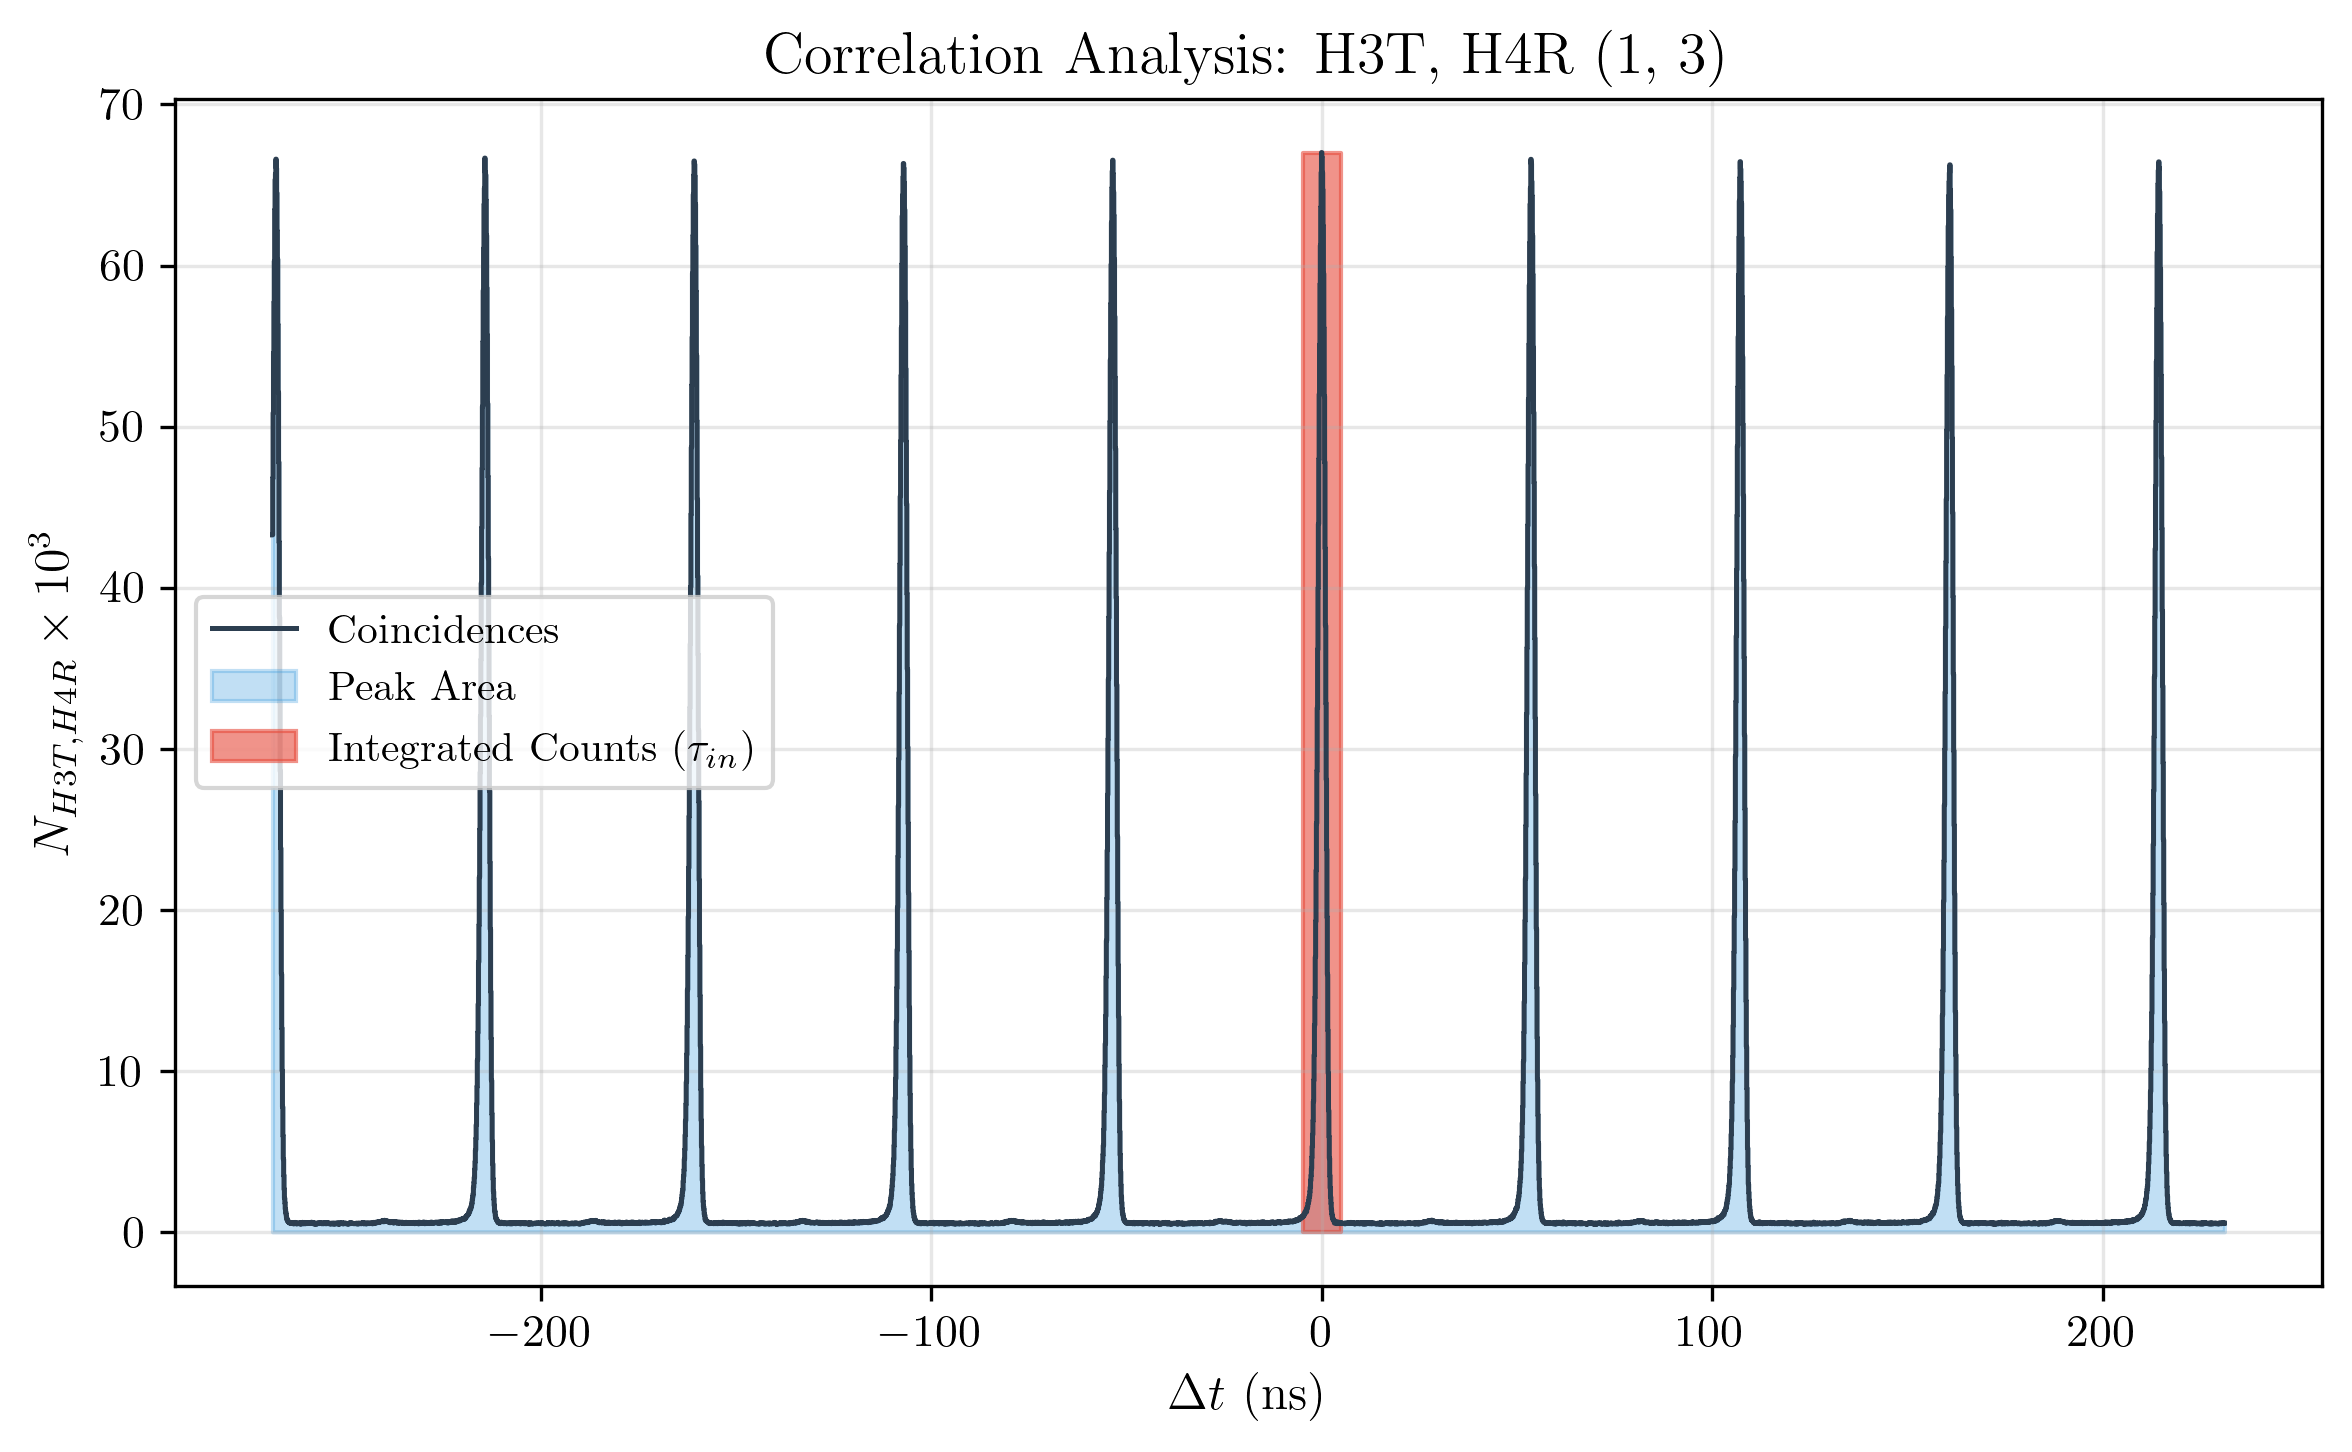

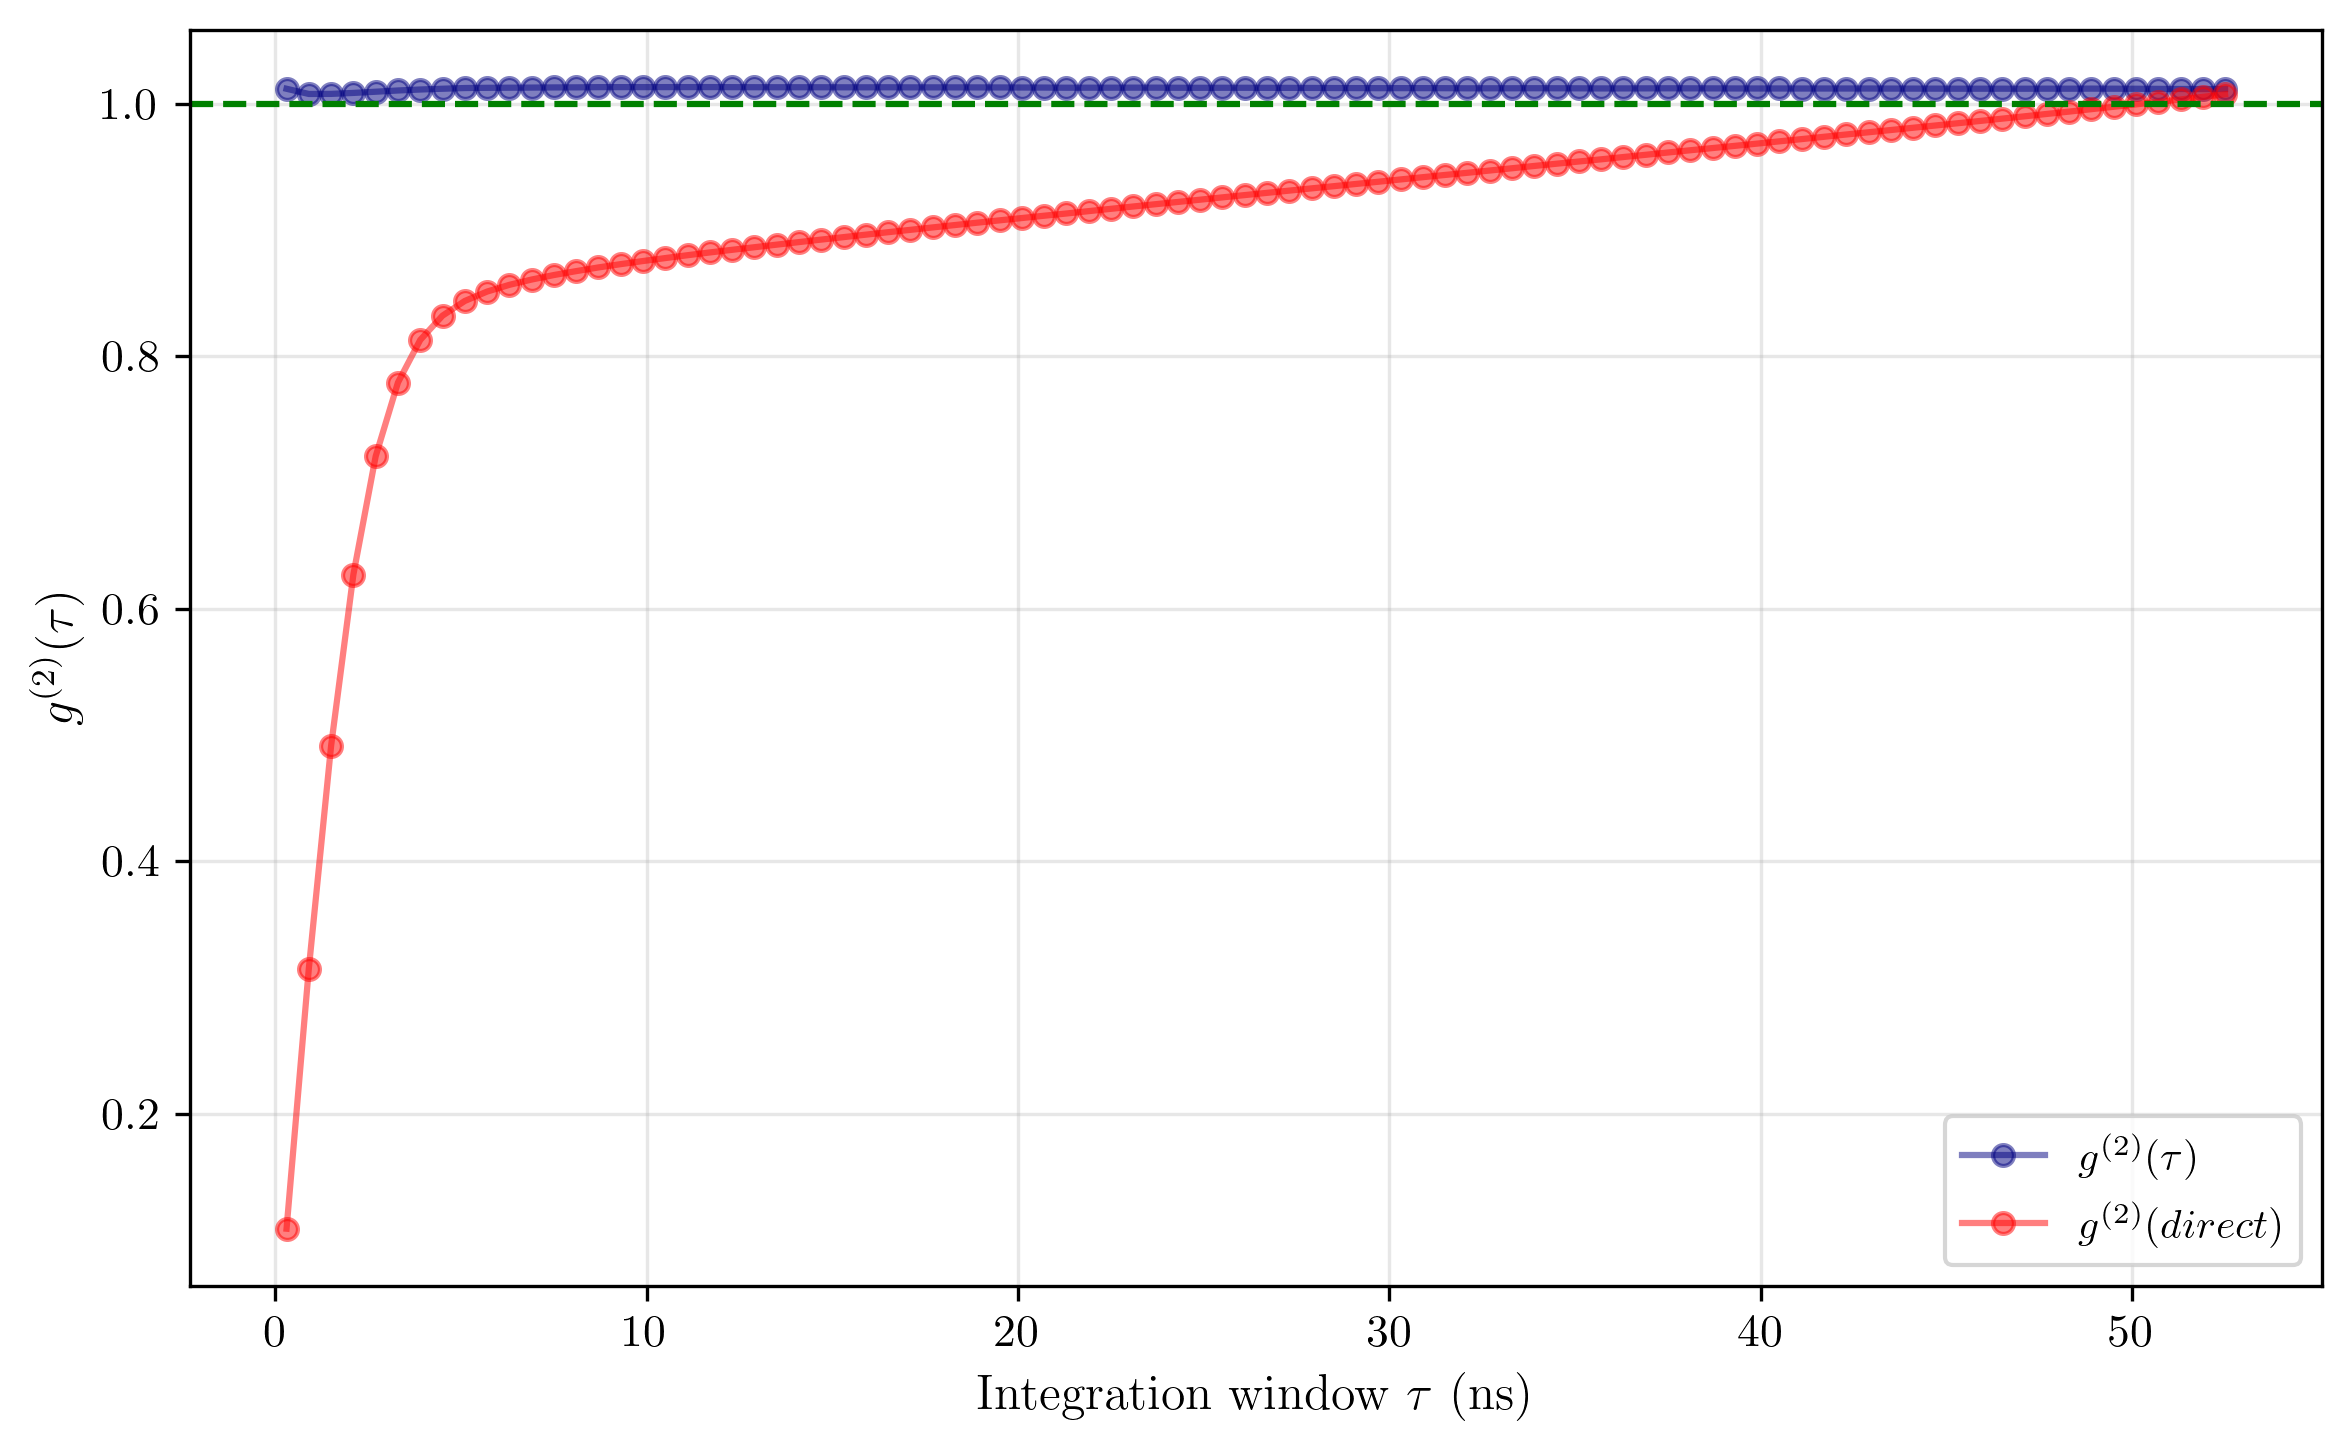

In [5]:
file_path = '/Users/simon.wtmn/Desktop/Quantum_SHHG/Data/1Apr_13mW.pkl'

run_april1 = HBTMeasurement(file_path)

first_channel = 1
second_channel = 3

run_april1.plot_correlation(first_channel, second_channel, show_shift=True, tau_in_ns=10)

tau_in_ns = np.arange(0.3, 53, 0.6)
g2_tau = []
g2_direct = []
for tau in tau_in_ns:
    g2_tau.append(run_april1.compute_g2_delay(first_channel, second_channel, tau, num_side_peaks=3))
    g2_direct.append(run_april1.compute_g2_direct(first_channel, second_channel, tau))

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
ax.plot(tau_in_ns, g2_tau, marker='o', linestyle='-', color='navy', markersize=5, alpha=0.5, label=r'$g^{(2)}(\tau)$')
ax.plot(tau_in_ns, g2_direct, marker='o', linestyle='-', color='red', markersize=5, alpha=0.5, label=r'$g^{(2)} (direct)$')
ax.set_xlabel(r"Integration window $\tau$ (ns)")
ax.set_ylabel(r"$g^{(2)}(\tau)$")
ax.axhline(y=1, color='green', linestyle='--')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()



In [6]:
g2_H3H4 = run_april1.compute_g2_delay(1, 3, 10, num_side_peaks=4)
g2_H3   = run_april1.compute_g2_delay(1, 2, 10, num_side_peaks=4)
g2_H4   = run_april1.compute_g2_delay(3, 4, 10, num_side_peaks=4)

print(g2_H3H4/(g2_H3*g2_H4))

0.7110422438763498
